<a href="https://colab.research.google.com/github/HimanshiChoubal/Linear_Regression1/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Manual Equation: Temp = (0.4263 * Month) + 9.1143
------------------------------
MAE (Mean Absolute Error): 6.9780
MSE (Mean Squared Error): 59.7361
R-Square Score: 0.0350
------------------------------


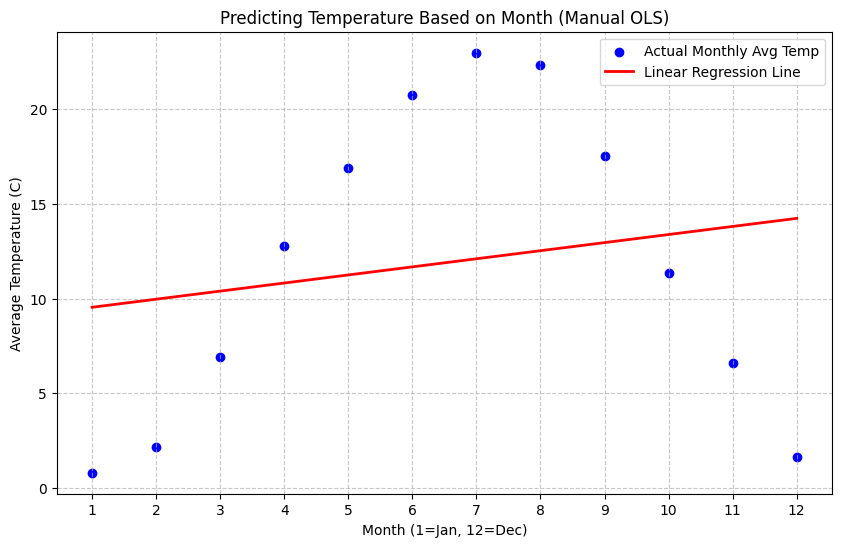

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = '/content/Assignment2-whetherHistory Dataset.xlsx - Sheet1.csv'
df = pd.read_csv(file_path)

df['Formatted_Date'] = pd.to_datetime(df['Formatted_Date'], utc=True)
df['Month'] = df['Formatted_Date'].dt.month

month_data = df.groupby('Month')['Temperature (C)'].mean().reset_index()

X = month_data['Month'].values
Y = month_data['Temperature (C)'].values

#  A:
mean_x = np.mean(X)
mean_y = np.mean(Y)

num = np.sum((X - mean_x) * (Y - mean_y))
den = np.sum((X - mean_x)**2)

m = num / den
c = mean_y - (m * mean_x)

Y_pred = m * X + c

#  B:
n = len(Y)
mae = np.sum(np.abs(Y - Y_pred)) / n
mse = np.sum((Y - Y_pred)**2) / n


ssr = np.sum((Y - Y_pred)**2)
sst = np.sum((Y - mean_y)**2)
r_squared = 1 - (ssr / sst)

print(f"Manual Equation: Temp = ({m:.4f} * Month) + {c:.4f}")
print("-" * 30)
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"R-Square Score: {r_squared:.4f}")
print("-" * 30)

#  C:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Actual Monthly Avg Temp')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Linear Regression Line')


plt.title('Predicting Temperature Based on Month (Manual OLS)')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average Temperature (C)')
plt.xticks(X)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()